## Week 3: Patient Similarity Modeling

With patient-level feature representations constructed in Week 2, the next
step is to evaluate whether early physiological patterns encode clinically
meaningful similarity. In this section, we model patient similarity using
distance-based methods and assess whether septic patients tend to cluster
together in the resulting feature space.

In [34]:
import pandas as pd
import numpy as np
#load and inspect saved patient features
patient_features = pd.read_csv("/Volumes/ExtremeSSD/Projects/agentic-sepsis-patient-similarity/data/processed/normalized_patient_features_24h_vitals_clean.csv")

In [35]:
patient_features.shape
patient_features.head()

,Patient_ID,HR_mean_24h,HR_min_24h,HR_max_24h,HR_std_24h,MAP_mean_24h,MAP_min_24h,MAP_max_24h,MAP_std_24h,O2Sat_mean_24h,...,SBP_std_24h,DBP_mean_24h,DBP_min_24h,DBP_max_24h,DBP_std_24h,Resp_mean_24h,Resp_min_24h,Resp_max_24h,Resp_std_24h,SepsisLabel
0,1,1.259368,0.508960,0.824223,0.327873,0.287258,-1.622100,1.466603,2.570669,-2.675308,...,1.640263,-1.431256e-15,7.447770e-16,0.000000,-1.369127,1.911626,1.238906,0.942669,0.533060,0
1,4,1.318203,1.728747,0.617334,-0.471874,-1.259350,-2.382130,-0.990353,0.028988,0.497472,...,-0.826913,-1.416962e+00,-7.712640e-01,-1.351663,-0.081593,0.123405,0.370217,0.012606,0.303229,0
2,5,-0.604345,-0.567322,-0.675723,-0.165082,0.273905,0.581987,-0.176082,-0.291889,0.165543,...,-0.662345,-1.431256e-15,7.447770e-16,0.000000,-1.369127,-0.595035,0.370217,-0.762446,-0.929587,0
3,6,1.153467,1.298234,0.513889,-0.210259,0.352520,0.581987,-0.304651,-0.102227,0.607751,...,0.087214,-1.431256e-15,7.447770e-16,0.000000,-1.369127,2.442886,1.673250,2.647783,3.260374,0
4,7,2.525815,2.446268,2.815530,0.668113,-0.722836,-0.482055,-0.218939,-0.369320,-0.820715,...,-0.339572,-5.911604e-01,-6.664460e-01,-0.209627,0.183283,0.733342,-0.208909,1.097679,1.215802,0


In [36]:
patient_features['SepsisLabel'].value_counts(normalize=True)

SepsisLabel
0    0.929408
1    0.070592
Name: proportion, dtype: float64

## Feature Engineering & Diagnostic Validation

This section focuses on constructing 24-hour aggregated vitals and validating their usefulness
through neighborhood-based diagnostic metrics prior to modeling.


In [37]:
#prepare data for similarity analysis
X = patient_features.drop(columns=['Patient_ID', 'SepsisLabel'])
y = patient_features['SepsisLabel']
X.isna().sum().sort_values(ascending=False).head(10)

HR_mean_24h       0
HR_min_24h        0
HR_max_24h        0
HR_std_24h        0
MAP_mean_24h      0
MAP_min_24h       0
MAP_max_24h       0
MAP_std_24h       0
O2Sat_mean_24h    0
O2Sat_min_24h     0
dtype: int64

In [38]:
X.isna().sum().sum()

np.int64(0)

### Similarity Model Selection
We begin with a k-nearest neighbors (kNN) approach using cosine distance.
Cosine similarity is commonly used in patient similarity and retrieval-based clinical modeling.

In [39]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=6,      # self + 5 neighbors
    metric='cosine'
)

knn.fit(X)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Retrieving Similar Patients

The following helper function retrieves the k most similar patients for a
given index patient based on cosine distance in the learned feature space.
This enables qualitative inspection of patient neighborhoods prior to
quantitative evaluation.


In [40]:
#function to get similar patients
def get_similar_patients(pat_id, k=5):
    idx = patient_features.index[
        patient_features['Patient_ID'] == pat_id
    ][0]
    
    distances, indices = knn.kneighbors(
        X.iloc[[idx]], n_neighbors=k+1
    )
    
    neighbors = patient_features.iloc[
        indices[0][1:]
    ][['Patient_ID', 'SepsisLabel']]
    
    return neighbors


In [41]:
get_similar_patients(patient_features.iloc[0]['Patient_ID'])


,Patient_ID,SepsisLabel
9155,12913,0
1466,2057,0
263,385,0
11142,15737,0
9385,13239,0


In [42]:
get_similar_patients(patient_features.iloc[10]['Patient_ID'])

,Patient_ID,SepsisLabel
3507,4950,0
4499,6362,0
4795,6774,0
9125,12873,0
1456,2044,0


In [50]:
get_similar_patients(patient_features.iloc[51]['Patient_ID'])

,Patient_ID,SepsisLabel
2265,3206,0
12648,17876,0
13308,18843,0
10541,14881,1
5810,8217,0


### Evaluating Clinical Coherence of Similarity

To assess whether the similarity space captures clinically meaningful
structure, we compute the proportion of septic patients among each patient's
nearest neighbors. Higher neighborhood sepsis prevalence among septic
patients would indicate that early physiological similarity aligns with
clinical outcomes.


In [51]:
def compute_neighbor_sepsis_rate(k=5):
    rates = []
    
    for i in range(len(X)):
        distances, indices = knn.kneighbors(
            X.iloc[[i]], n_neighbors=k+1
        )
        neighbor_labels = y.iloc[
            indices[0][1:]
        ]
        rates.append(neighbor_labels.mean())
    
    return rates

### Diagnostic Check 2: Neighborhood Signal Construction

We computed the mean sepsis prevalence among each patient's k-nearest neighbors
to capture local patient-context risk beyond individual vitals.

This feature is evaluated for class separation prior to modeling.

In [52]:
patient_features['neighbor_sepsis_rate'] = compute_neighbor_sepsis_rate()

### Neighborhood Analysis Visualization

We visualize neighborhood sepsis prevalence stratified by patient sepsis
status to compare similarity behavior across cohorts.


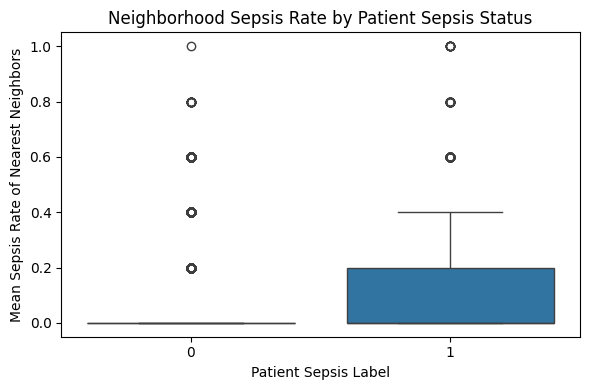

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    x='SepsisLabel',
    y='neighbor_sepsis_rate',
    data=patient_features
)
plt.title("Neighborhood Sepsis Rate by Patient Sepsis Status")
plt.xlabel("Patient Sepsis Label")
plt.ylabel("Mean Sepsis Rate of Nearest Neighbors")
plt.tight_layout()
plt.show()


### Diagnostic Check 3: Neighborhood Sepsis Prevalence Stratification

This visualization compares neighborhood sepsis prevalence stratified by patient sepsis status.

**Observations:**
- Non-sepsis patients show neighborhood rates tightly concentrated near zero
- Sepsis patients exhibit a broader distribution with higher median values
- This indicates meaningful neighborhood-level signal without obvious label leakage

This diagnostic validates the neighborhood feature as a candidate predictive signal.


Septic patients demonstrate higher neighborhood sepsis prevalence compared to
non-septic patients, indicating that early physiological similarity captures
clinically meaningful structure despite expected overlap.
